In [22]:
# Volumes:

A_SSN095_cm2 = (0.5*0.5)   #cm2
A_SSN101_cm2 = (0.5*0.5)   #cm2
A_SSN103_cm2 = (0.4*0.5)   #cm2

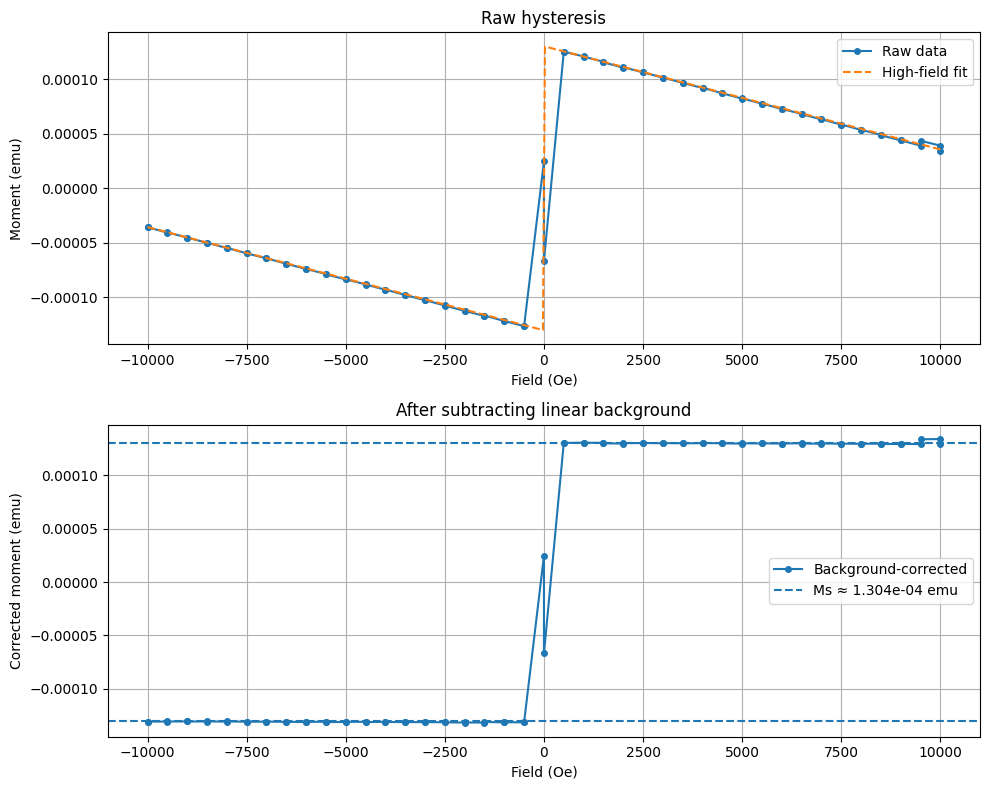

=== Fit results SSN095 ===
Linear background slope chi  = -9.480026e-09 emu/Oe
Ms from fit                 = 1.304451e-04 emu
Ms from +high-field branch  = 1.300011e-04 emu
Ms from -high-field branch  = 1.308891e-04 emu
Ms average                  = 1.304451e-04 emu
Ms = 1304.451 emu/cm^3
Ms = 1304451.073 A/m


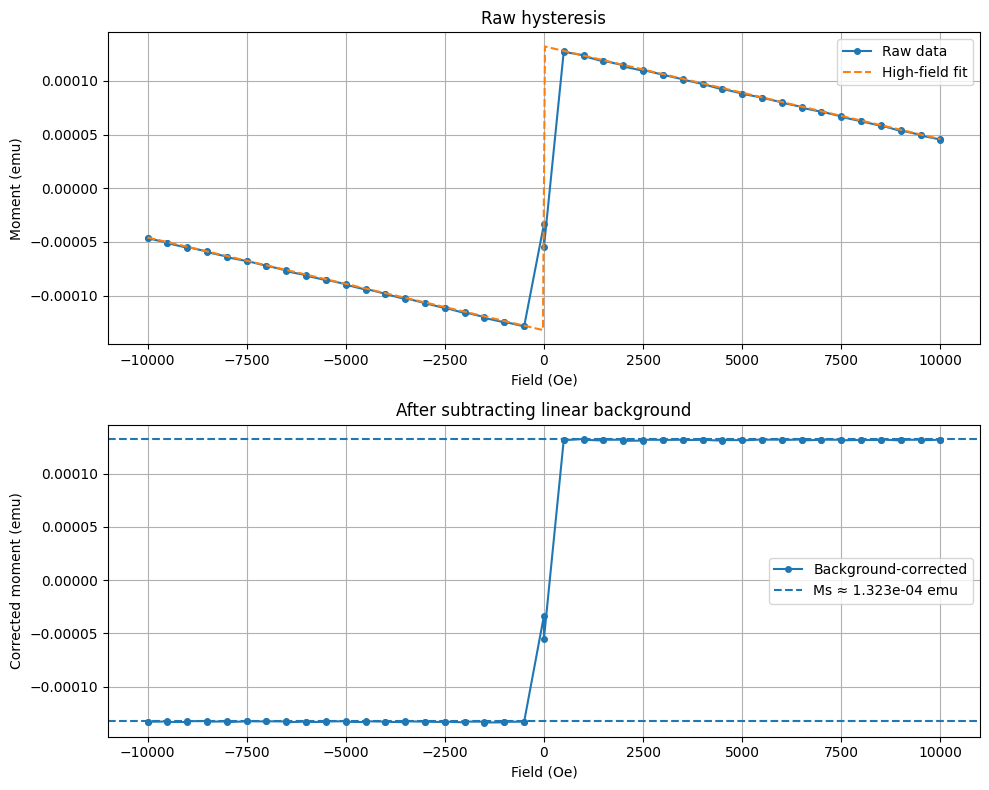

=== Fit results SSN101 ===
Linear background slope chi  = -8.647944e-09 emu/Oe
Ms from fit                 = 1.323264e-04 emu
Ms from +high-field branch  = 1.317029e-04 emu
Ms from -high-field branch  = 1.329498e-04 emu
Ms average                  = 1.323264e-04 emu
Ms = 1323.264 emu/cm^3
Ms = 1323263.829 A/m


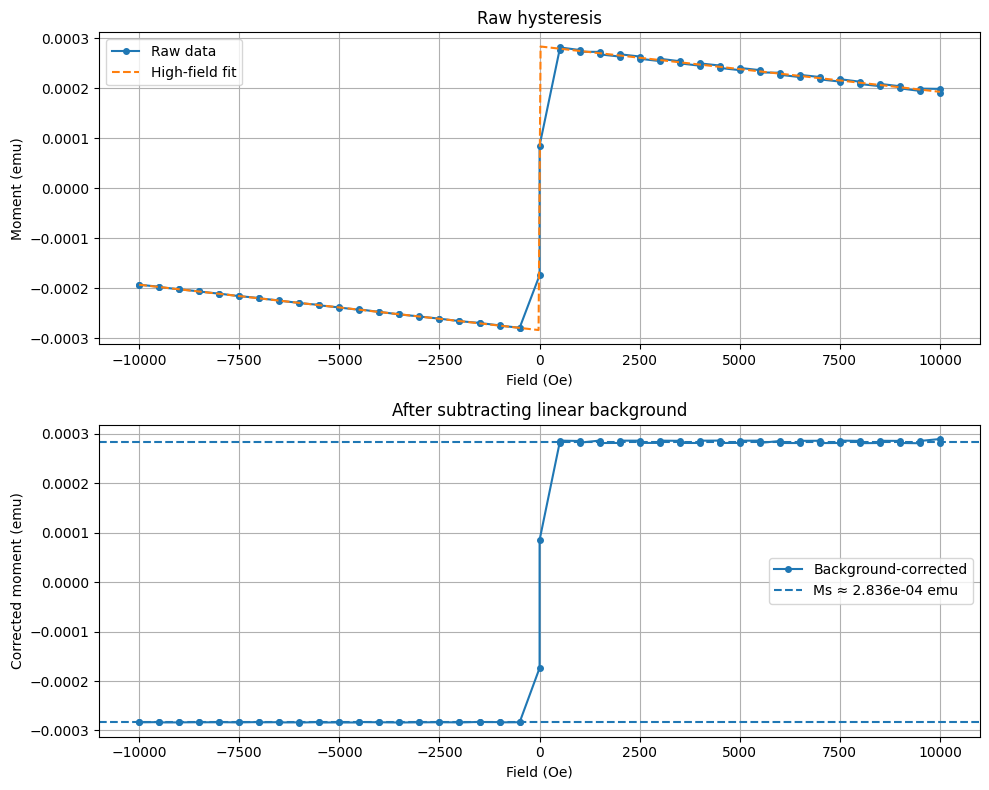

=== Fit results SSN103 ===
Linear background slope chi  = -9.075847e-09 emu/Oe
Ms from fit                 = 2.835534e-04 emu
Ms from +high-field branch  = 2.836369e-04 emu
Ms from -high-field branch  = 2.834699e-04 emu
Ms average                  = 2.835534e-04 emu
Ms = 1417.767 emu/cm^3
Ms = 1417767.001 A/m


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO


def read_mpms_dat(filepath):
    """
    Read a Quantum Design MPMS .dat file and return a pandas DataFrame
    containing the [Data] section.
    """
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    # Find the [Data] section
    data_start = None
    for i, line in enumerate(lines):
        if line.strip() == "[Data]":
            data_start = i + 1
            break

    if data_start is None:
        raise ValueError("Could not find [Data] section in file.")

    csv_text = "".join(lines[data_start:])
    df = pd.read_csv(StringIO(csv_text))
    return df


def estimate_saturation_moment(
    df,
    field_col="Field (Oe)",
    moment_col="Long Moment (emu)",
    high_field_fraction=0.2,
    plot=True,
):
    """
    Estimate saturation moment Ms from a field sweep with linear background.

    Model on high-field data:
        m(H) = chi * H + sign(H) * Ms

    Parameters
    ----------
    df : pandas.DataFrame
    field_col : str
        Column name for field in Oe.
    moment_col : str
        Column name for magnetic moment in emu.
    high_field_fraction : float
        Use points with |H| >= high_field_fraction * max(|H|) for the fit.
        Typical values: 0.6 to 0.85
    plot : bool
        Whether to show diagnostic plots.

    Returns
    -------
    results : dict
        Dictionary with fitted parameters and corrected data.
    """
    data = df[[field_col, moment_col]].copy()
    data = data.replace([np.inf, -np.inf], np.nan).dropna()

    H = data[field_col].to_numpy(dtype=float)
    m = data[moment_col].to_numpy(dtype=float)

    # Sort by field for cleaner plotting
    order = np.argsort(H)
    H = H[order]
    m = m[order]

    Hmax = np.max(np.abs(H))
    mask_hf = np.abs(H) >= high_field_fraction * Hmax

    if mask_hf.sum() < 4:
        raise ValueError(
            "Not enough high-field points for fitting. "
            "Try lowering high_field_fraction."
        )

    H_hf = H[mask_hf]
    m_hf = m[mask_hf]
    s_hf = np.sign(H_hf)

    # Linear least-squares fit:
    # m = chi * H + Ms * sign(H)
    A = np.column_stack([H_hf, s_hf])
    coeff, residuals, rank, svals = np.linalg.lstsq(A, m_hf, rcond=None)
    chi, Ms_fit = coeff

    # Background-corrected moment
    m_corr = m - chi * H

    # Estimate positive and negative saturation plateaus from corrected data
    pos_mask = H >= high_field_fraction * Hmax
    neg_mask = H <= -high_field_fraction * Hmax

    Ms_pos = np.mean(m_corr[pos_mask]) if np.any(pos_mask) else np.nan
    Ms_neg = np.mean(-m_corr[neg_mask]) if np.any(neg_mask) else np.nan
    Ms_avg = np.nanmean([Ms_pos, Ms_neg])

    results = {
        "chi_emu_per_Oe": chi,
        "Ms_fit_emu": Ms_fit,
        "Ms_pos_emu": Ms_pos,
        "Ms_neg_emu": Ms_neg,
        "Ms_avg_emu": Ms_avg,
        "H_Oe": H,
        "m_emu": m,
        "m_corr_emu": m_corr,
        "high_field_mask": mask_hf,
    }

    if plot:
        fig, ax = plt.subplots(2, 1, figsize=(10, 8))

        # Raw data + fit
        ax[0].plot(H, m, "o-", ms=4, label="Raw data")
        Hfit = np.linspace(H.min(), H.max(), 400)
        mfit = chi * Hfit + np.sign(Hfit) * Ms_fit
        ax[0].plot(Hfit, mfit, "--", label="High-field fit")
        ax[0].set_xlabel("Field (Oe)")
        ax[0].set_ylabel("Moment (emu)")
        ax[0].set_title("Raw hysteresis")
        ax[0].legend()
        ax[0].grid(True)

        # Corrected data
        ax[1].plot(H, m_corr, "o-", ms=4, label="Background-corrected")
        ax[1].axhline(Ms_avg, linestyle="--", label=f"Ms ≈ {Ms_avg:.3e} emu")
        ax[1].axhline(-Ms_avg, linestyle="--")
        ax[1].set_xlabel("Field (Oe)")
        ax[1].set_ylabel("Corrected moment (emu)")
        ax[1].set_title("After subtracting linear background")
        ax[1].legend()
        ax[1].grid(True)

        plt.tight_layout()
        plt.show()

    return results


def convert_moment_to_magnetization(Ms_emu, mass_mg=None, area_cm2=None, thickness_cm=None):
    """
    Convert saturation moment to common magnetization units if geometry is known.

    Returns a dict with possible conversions:
    - emu/g if mass is given
    - emu/cm^3 if area and thickness are given
    """
    out = {"Ms_emu": Ms_emu}

    if mass_mg is not None and mass_mg > 0:
        mass_g = mass_mg / 1000.0
        out["Ms_emu_per_g"] = Ms_emu / mass_g

    if area_cm2 is not None and thickness_cm is not None and area_cm2 > 0 and thickness_cm > 0:
        volume_cm3 = area_cm2 * thickness_cm
        out["Ms_emu_per_cm3"] = Ms_emu / volume_cm3

    return out

def saturation_magnetization_from_volume(ms_emu, area_cm2, thickness_cm):
    """
    Convert saturation moment (emu) to saturation magnetization (emu/cm^3).

    Parameters
    ----------
    ms_emu : float
        Saturation moment in emu.
    area_cm2 : float
        Sample area in cm^2.
    thickness_cm : float
        Sample thickness in cm.

    Returns
    -------
    ms_emu_cm3 : float
        Saturation magnetization in emu/cm^3.
    ms_A_m : float
        Saturation magnetization in A/m.
    """
    volume_cm3 = area_cm2 * thickness_cm
    ms_emu_cm3 = ms_emu / volume_cm3
    ms_A_m = ms_emu_cm3 * 1000.0
    return ms_emu_cm3, ms_A_m

# Replace with your file path
filepath = ".\\SSN095\\SSN095_IP.rso.dat"

df = read_mpms_dat(filepath)

results = estimate_saturation_moment(
    df,
    field_col="Field (Oe)",
    moment_col="Long Moment (emu)",
    high_field_fraction=0.3,   # adjust if needed
    plot=True,
)

print("=== Fit results SSN095 ===")
print(f"Linear background slope chi  = {results['chi_emu_per_Oe']:.6e} emu/Oe")
print(f"Ms from fit                 = {results['Ms_fit_emu']:.6e} emu")
print(f"Ms from +high-field branch  = {results['Ms_pos_emu']:.6e} emu")
print(f"Ms from -high-field branch  = {results['Ms_neg_emu']:.6e} emu")
print(f"Ms average                  = {results['Ms_avg_emu']:.6e} emu")
Ms_moment = results["Ms_avg_emu"]   # from the SQUID fit

thickness_cm = 4e-7     # 50 nm = 5e-6 cm

Ms_vol, Ms_Am = saturation_magnetization_from_volume(
    Ms_moment, A_SSN095_cm2, 4e-7
)

print(f"Ms = {Ms_vol:.3f} emu/cm^3")
print(f"Ms = {Ms_Am:.3f} A/m")

# Replace with your file path
filepath = ".\\SSN101\\SSN101_IP.rso.dat"

df = read_mpms_dat(filepath)

results = estimate_saturation_moment(
    df,
    field_col="Field (Oe)",
    moment_col="Long Moment (emu)",
    high_field_fraction=0.3,   # adjust if needed
    plot=True,
)

print("=== Fit results SSN101 ===")
print(f"Linear background slope chi  = {results['chi_emu_per_Oe']:.6e} emu/Oe")
print(f"Ms from fit                 = {results['Ms_fit_emu']:.6e} emu")
print(f"Ms from +high-field branch  = {results['Ms_pos_emu']:.6e} emu")
print(f"Ms from -high-field branch  = {results['Ms_neg_emu']:.6e} emu")
print(f"Ms average                  = {results['Ms_avg_emu']:.6e} emu")
Ms_moment = results["Ms_avg_emu"]   # from the SQUID fit

thickness_cm = 4e-7     # 50 nm = 5e-6 cm

Ms_vol, Ms_Am = saturation_magnetization_from_volume(
    Ms_moment, A_SSN101_cm2, 4e-7
)

print(f"Ms = {Ms_vol:.3f} emu/cm^3")
print(f"Ms = {Ms_Am:.3f} A/m")


# Replace with your file path
filepath = ".\\SSN103\\SSN103_IP.rso.dat"

df = read_mpms_dat(filepath)

results = estimate_saturation_moment(
    df,
    field_col="Field (Oe)",
    moment_col="Long Moment (emu)",
    high_field_fraction=0.3,   # adjust if needed
    plot=True,
)

print("=== Fit results SSN103 ===")
print(f"Linear background slope chi  = {results['chi_emu_per_Oe']:.6e} emu/Oe")
print(f"Ms from fit                 = {results['Ms_fit_emu']:.6e} emu")
print(f"Ms from +high-field branch  = {results['Ms_pos_emu']:.6e} emu")
print(f"Ms from -high-field branch  = {results['Ms_neg_emu']:.6e} emu")
print(f"Ms average                  = {results['Ms_avg_emu']:.6e} emu")
Ms_moment = results["Ms_avg_emu"]   # from the SQUID fit

thickness_cm = 10e-7     # 50 nm = 5e-6 cm

Ms_vol, Ms_Am = saturation_magnetization_from_volume(
    Ms_moment, A_SSN103_cm2, 10e-7
)

print(f"Ms = {Ms_vol:.3f} emu/cm^3")
print(f"Ms = {Ms_Am:.3f} A/m")

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO


def read_mpms_dat(filepath):
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    data_start = None
    for i, line in enumerate(lines):
        if line.strip() == "[Data]":
            data_start = i + 1
            break

    if data_start is None:
        raise ValueError("Could not find [Data] section in file.")

    csv_text = "".join(lines[data_start:])
    return pd.read_csv(StringIO(csv_text))


def estimate_saturation_moment_with_error(
    df,
    field_col="Field (Oe)",
    moment_col="Long Moment (emu)",
    high_field_fraction=0.7,
    plot=True,
):
    """
    Fit high-field data to:
        m(H) = chi * H + sign(H) * Ms

    Returns fitted Ms and its 1-sigma uncertainty from the covariance matrix.
    Also reports plateau-based estimates from corrected data.
    """
    data = df[[field_col, moment_col]].copy()
    data = data.replace([np.inf, -np.inf], np.nan).dropna()

    H = data[field_col].to_numpy(dtype=float)
    m = data[moment_col].to_numpy(dtype=float)

    order = np.argsort(H)
    H = H[order]
    m = m[order]

    Hmax = np.max(np.abs(H))
    mask_hf = np.abs(H) >= high_field_fraction * Hmax

    if mask_hf.sum() < 4:
        raise ValueError("Not enough high-field points for fitting.")

    H_hf = H[mask_hf]
    m_hf = m[mask_hf]
    s_hf = np.sign(H_hf)

    # Design matrix: m = chi*H + Ms*sign(H)
    A = np.column_stack([H_hf, s_hf])

    # Least-squares solution
    coeff, residuals, rank, svals = np.linalg.lstsq(A, m_hf, rcond=None)
    chi, Ms_fit = coeff

    # Residual variance estimate
    n = len(m_hf)
    p = A.shape[1]  # number of fit parameters = 2
    dof = n - p
    if dof <= 0:
        raise ValueError("Not enough degrees of freedom to estimate fit uncertainty.")

    fit_residuals = m_hf - A @ coeff
    sigma2 = np.sum(fit_residuals**2) / dof

    # Covariance matrix of fitted parameters
    cov = sigma2 * np.linalg.inv(A.T @ A)
    chi_err = np.sqrt(cov[0, 0])
    Ms_fit_err = np.sqrt(cov[1, 1])

    # Background-corrected moment
    m_corr = m - chi * H

    # Plateau averages from corrected data
    pos_mask = H >= high_field_fraction * Hmax
    neg_mask = H <= -high_field_fraction * Hmax

    Ms_pos = np.mean(m_corr[pos_mask]) if np.any(pos_mask) else np.nan
    Ms_neg = np.mean(-m_corr[neg_mask]) if np.any(neg_mask) else np.nan
    Ms_avg = np.nanmean([Ms_pos, Ms_neg])

    # Scatter-based uncertainties of plateau estimates
    Ms_pos_err = (
        np.std(m_corr[pos_mask], ddof=1) / np.sqrt(np.sum(pos_mask))
        if np.sum(pos_mask) > 1 else np.nan
    )
    Ms_neg_err = (
        np.std(-m_corr[neg_mask], ddof=1) / np.sqrt(np.sum(neg_mask))
        if np.sum(neg_mask) > 1 else np.nan
    )

    # Combine positive/negative branch standard errors
    plateau_errs = [x for x in [Ms_pos_err, Ms_neg_err] if np.isfinite(x)]
    Ms_avg_err = np.sqrt(np.sum(np.array(plateau_errs) ** 2)) / len(plateau_errs) if plateau_errs else np.nan

    results = {
        "chi_emu_per_Oe": chi,
        "chi_err_emu_per_Oe": chi_err,
        "Ms_fit_emu": Ms_fit,
        "Ms_fit_err_emu": Ms_fit_err,
        "Ms_pos_emu": Ms_pos,
        "Ms_pos_err_emu": Ms_pos_err,
        "Ms_neg_emu": Ms_neg,
        "Ms_neg_err_emu": Ms_neg_err,
        "Ms_avg_emu": Ms_avg,
        "Ms_avg_err_emu": Ms_avg_err,
        "H_Oe": H,
        "m_emu": m,
        "m_corr_emu": m_corr,
        "high_field_mask": mask_hf,
    }

    if plot:
        fig, ax = plt.subplots(1, 2, figsize=(12, 5))

        ax[0].plot(H, m, "o-", ms=4, label="Raw data")
        ax[0].plot(H_hf, m_hf, "ro", ms=5, label="Fit points")
        Hfit = np.linspace(H.min(), H.max(), 400)
        mfit = chi * Hfit + np.sign(Hfit) * Ms_fit
        ax[0].plot(Hfit, mfit, "--", label="High-field fit")
        ax[0].set_xlabel("Field (Oe)", fontsize=13)
        ax[0].set_ylabel("Moment (emu)", fontsize=13)
        ax[0].set_title("Raw hysteresis", fontsize=15)
        ax[0].legend()
        ax[0].grid(True)

        ax[1].plot(H, m_corr, "o-", ms=4, label="Background-corrected")
        ax[1].axhline(Ms_fit, linestyle="--", label=f"Ms = {Ms_fit:.3e} ± {Ms_fit_err:.1e} emu")
        ax[1].axhline(-Ms_fit, linestyle="--")
        ax[1].set_xlabel("Field (Oe)", fontsize=13)
        ax[1].set_ylabel("Corrected moment (emu)", fontsize=13)
        ax[1].set_title("Corrected loop", fontsize=15)
        # ax[1].legend()
        ax[1].grid(True)

        plt.tight_layout()
        plt.show()

    return results


def saturation_magnetization_from_volume_with_error(
    ms_emu,
    ms_err_emu,
    area_cm2,
    thickness_cm,
    area_err_cm2=None,
    thickness_err_cm=None,
):
    """
    Convert saturation moment to saturation magnetization with error propagation.

    Returns:
        Ms_vol_emu_cm3
        Ms_vol_err_emu_cm3
        Ms_A_per_m
        Ms_err_A_per_m
    """
    V = area_cm2 * thickness_cm
    Ms_vol = ms_emu / V

    # Start with moment uncertainty only
    rel2 = (ms_err_emu / ms_emu) ** 2 if ms_emu != 0 else np.nan

    # Add area/thickness uncertainty if provided
    if area_err_cm2 is not None and area_cm2 > 0:
        rel2 += (area_err_cm2 / area_cm2) ** 2
    if thickness_err_cm is not None and thickness_cm > 0:
        rel2 += (thickness_err_cm / thickness_cm) ** 2

    Ms_vol_err = abs(Ms_vol) * np.sqrt(rel2)

    # 1 emu/cm^3 = 1000 A/m
    Ms_A_m = Ms_vol * 1000.0
    Ms_err_A_m = Ms_vol_err * 1000.0

    return {
        "volume_cm3": V,
        "Ms_emu_per_cm3": Ms_vol,
        "Ms_err_emu_per_cm3": Ms_vol_err,
        "Ms_A_per_m": Ms_A_m,
        "Ms_err_A_per_m": Ms_err_A_m,
    }

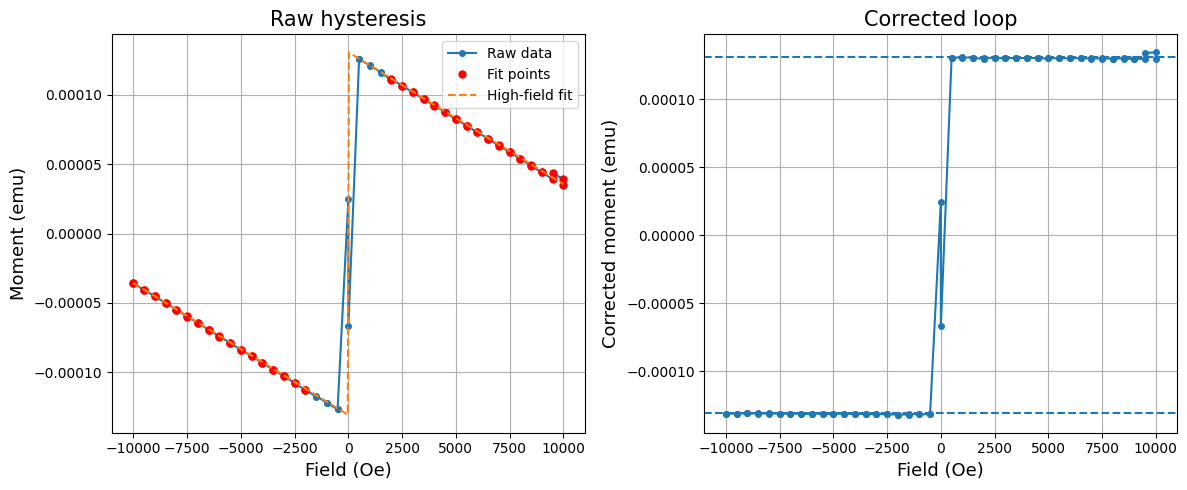


=== Fit results SSN095 ===
Linear background slope chi  = -9.503745e-09 ± 4.37e-11 emu/Oe
Ms from fit                 = 1.306255e-04 ± 2.83e-07 emu
Ms from +high-field branch  = 1.301506e-04 ± 1.75e-07 emu
Ms from -high-field branch  = 1.311004e-04 ± 4.02e-08 emu
Ms average                  = 1.306255e-04 ± 8.97e-08 emu
Volume                      = 1.000000e-07 cm^3
Ms                          = 1306.255 ± 104.539 emu/cm^3
Ms                          = 1306254.968 ± 104538.784 A/m


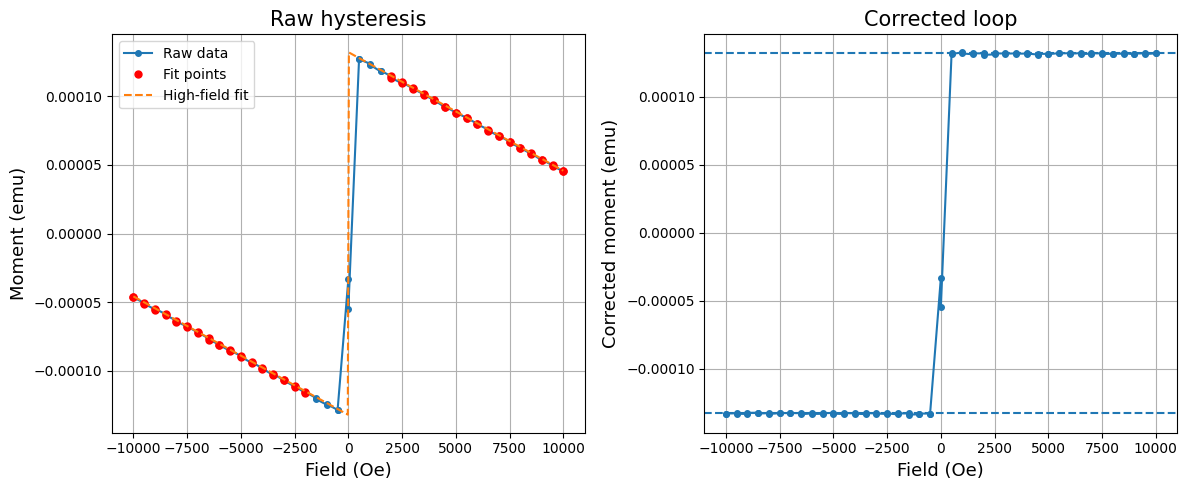


=== Fit results SSN101 ===
Linear background slope chi  = -8.647146e-09 ± 3.65e-11 emu/Oe
Ms from fit                 = 1.323202e-04 ± 2.37e-07 emu
Ms from +high-field branch  = 1.316661e-04 ± 5.60e-08 emu
Ms from -high-field branch  = 1.329744e-04 ± 5.40e-08 emu
Ms average                  = 1.323202e-04 ± 3.89e-08 emu
Volume                      = 1.000000e-07 cm^3
Ms                          = 1323.202 ± 105.883 emu/cm^3
Ms                          = 1323202.473 ± 105882.634 A/m


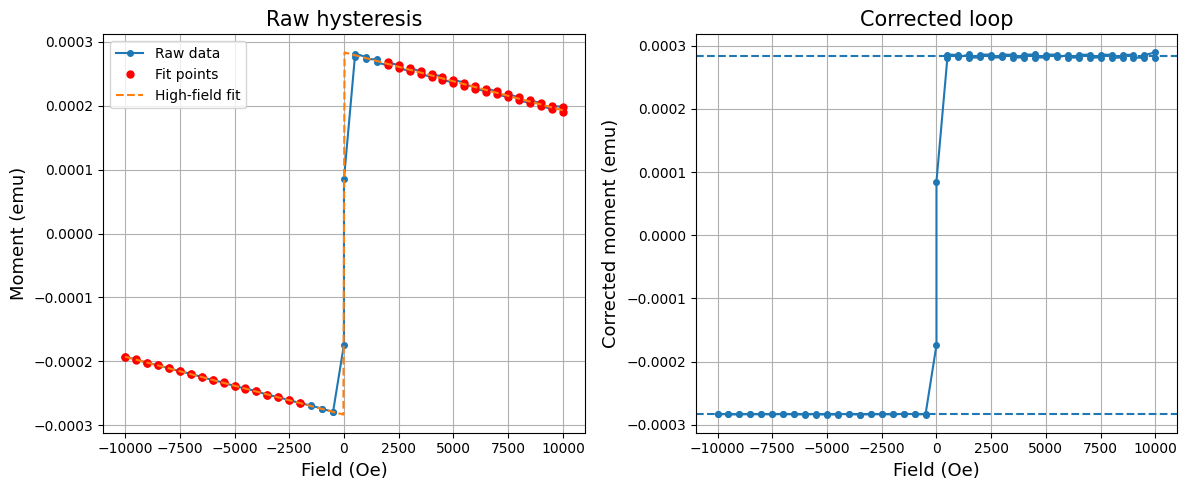


=== Fit results SSN103 ===
Linear background slope chi  = -9.079877e-09 ± 8.83e-11 emu/Oe
Ms from fit                 = 2.835833e-04 ± 5.72e-07 emu
Ms from +high-field branch  = 2.836733e-04 ± 4.29e-07 emu
Ms from -high-field branch  = 2.834934e-04 ± 4.67e-08 emu
Ms average                  = 2.835833e-04 ± 2.16e-07 emu
Volume                      = 2.000000e-07 cm^3
Ms                          = 1417.917 ± 141.821 emu/cm^3
Ms                          = 1417916.743 ± 141820.528 A/m


In [32]:
# =========================
# Sample-specific settings
# =========================

samples = [
    {
        "name": "SSN095",
        "filepath": r".\SSN095\SSN095_IP.rso.dat",
        "area_cm2": A_SSN095_cm2,
        "area_err": 0.02,
        "thickness_cm": 4e-7,      # 4 nm
        "high_field_fraction": 0.2,
    },
    {
        "name": "SSN101",
        "filepath": r".\SSN101\SSN101_IP.rso.dat",
        "area_cm2": A_SSN101_cm2,
        "area_err": 0.02,
        "thickness_cm": 4e-7,      # 4 nm
        "high_field_fraction": 0.2,
    },
    {
        "name": "SSN103",
        "filepath": r".\SSN103\SSN103_IP.rso.dat",
        "area_cm2": A_SSN103_cm2,
        "area_err": 0.02,
        "thickness_cm": 10e-7,     # 10 nm
        "high_field_fraction": 0.2,
    },
]

# Optional geometry uncertainties
# Set to None if you do not want to include them
default_area_err_cm2 = None
default_thickness_err_cm = None
# example:
# default_thickness_err_cm = 0.5e-7   # 0.5 nm


# =========================
# Analysis loop
# =========================

all_results = {}

for sample in samples:
    name = sample["name"]
    filepath = sample["filepath"]
    area_cm2 = sample["area_cm2"]
    area_err = sample["area_err"]
    thickness_cm = sample["thickness_cm"]
    high_field_fraction = sample["high_field_fraction"]

    df = read_mpms_dat(filepath)

    results = estimate_saturation_moment_with_error(
        df,
        field_col="Field (Oe)",
        moment_col="Long Moment (emu)",
        high_field_fraction=high_field_fraction,
        plot=True,
    )

    # Choose which moment estimate to use for volume normalization:
    # Option 1: fit-based
    ms_emu = results["Ms_fit_emu"]
    ms_err_emu = results["Ms_fit_err_emu"]

    # Option 2: plateau-average-based
    # ms_emu = results["Ms_avg_emu"]
    # ms_err_emu = results["Ms_avg_err_emu"]

    vol_results = saturation_magnetization_from_volume_with_error(
        ms_emu=ms_emu,
        ms_err_emu=ms_err_emu,
        area_cm2=area_cm2,
        thickness_cm=thickness_cm,
        area_err_cm2=area_err,
        thickness_err_cm=default_thickness_err_cm,
    )

    print(f"\n=== Fit results {name} ===")
    print(f"Linear background slope chi  = {results['chi_emu_per_Oe']:.6e} ± {results['chi_err_emu_per_Oe']:.2e} emu/Oe")
    print(f"Ms from fit                 = {results['Ms_fit_emu']:.6e} ± {results['Ms_fit_err_emu']:.2e} emu")
    print(f"Ms from +high-field branch  = {results['Ms_pos_emu']:.6e} ± {results['Ms_pos_err_emu']:.2e} emu")
    print(f"Ms from -high-field branch  = {results['Ms_neg_emu']:.6e} ± {results['Ms_neg_err_emu']:.2e} emu")
    print(f"Ms average                  = {results['Ms_avg_emu']:.6e} ± {results['Ms_avg_err_emu']:.2e} emu")

    print(f"Volume                      = {vol_results['volume_cm3']:.6e} cm^3")
    print(
        f"Ms                          = "
        f"{vol_results['Ms_emu_per_cm3']:.3f} ± {vol_results['Ms_err_emu_per_cm3']:.3f} emu/cm^3"
    )
    print(
        f"Ms                          = "
        f"{vol_results['Ms_A_per_m']:.3f} ± {vol_results['Ms_err_A_per_m']:.3f} A/m"
    )

    all_results[name] = {
        "moment_fit": results,
        "volume_fit": vol_results,
    }

In [27]:
import numpy as np

def area_and_error_from_rectangle(length_cm, width_cm, length_err_cm, width_err_cm):
    area_cm2 = length_cm * width_cm
    rel_err2 = (length_err_cm / length_cm)**2 + (width_err_cm / width_cm)**2
    area_err_cm2 = area_cm2 * np.sqrt(rel_err2)
    return area_cm2, area_err_cm2

L_cm = 0.50
W_cm = 0.50
L_err_cm = 0.05
W_err_cm = 0.05

A_SSN095_cm2, A_SSN095_err_cm2 = area_and_error_from_rectangle(
    L_cm, W_cm, L_err_cm, W_err_cm
)
print(A_SSN095_err_cm2)

0.03535533905932738
